In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_hub as hub

In [2]:
model_url = "https://tfhub.dev/google/yamnet/1"
yamnet_model=hub.load(model_url)

In [3]:
def load_audio(file_path):
    audio=tf.io.read_file(file_path)
    audio,sample_rate=tf.audio.decode_wav(audio)
    return  tf.squeeze(audio,axis=1),sample_rate

In [4]:
audio_file_path='Voice.wav'
waveform,sample_rate=load_audio(audio_file_path)

Sample rate: 48000 Hz
Waveform shape: (209844,)


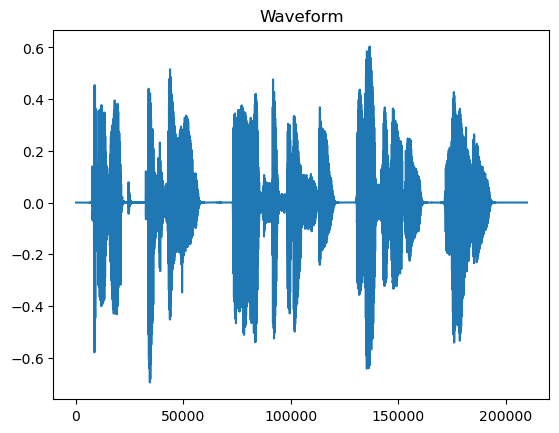

In [5]:
# Проверка длины аудио и его график
print(f"Sample rate: {sample_rate.numpy()} Hz")
print(f"Waveform shape: {waveform.shape}")
plt.plot(waveform.numpy())
plt.title("Waveform")
plt.show()

In [6]:
class_map_path = yamnet_model.class_map_path().numpy().decode("utf-8")
class_names = np.array([name for name in open(class_map_path).read().splitlines()])

In [7]:
def predict(audio):
    scores, embeddings, spectrogram = yamnet_model(audio)
    scores_np = scores.numpy()
    return scores_np

In [8]:
scores = predict(waveform)

In [9]:
predicted_class = class_names[scores.mean(axis=0).argmax()]
print(f"Predicted class: {predicted_class}")

Predicted class: index,mid,display_name


In [11]:
for i in range(len(class_names)-1):
    print(f"{class_names[i]}: {scores.mean(axis=0)[i]}")

index,mid,display_name: 0.24294649064540863
0,/m/09x0r,Speech: 0.00045351681183092296
1,/m/0ytgt,"Child speech, kid speaking": 0.004660624545067549
2,/m/01h8n0,Conversation: 0.008861384354531765
3,/m/02qldy,"Narration, monologue": 2.2148050504711136e-07
4,/m/0261r1,Babbling: 0.014982260763645172
5,/m/0brhx,Speech synthesizer: 0.0002480032271705568
6,/m/07p6fty,Shout: 0.00023555864754598588
7,/m/07q4ntr,Bellow: 7.54244756535627e-05
8,/m/07rwj3x,Whoop: 1.139755295298528e-05
9,/m/07sr1lc,Yell: 1.0968789210252794e-09
10,/t/dd00135,Children shouting: 4.600357715389691e-05
11,/m/03qc9zr,Screaming: 6.159460463095456e-05
12,/m/02rtxlg,Whispering: 0.00018967092910315841
13,/m/01j3sz,Laughter: 4.15244620910471e-08
14,/t/dd00001,Baby laughter: 5.631187036669871e-07
15,/m/07r660_,Giggle: 1.1802940207417123e-05
16,/m/07s04w4,Snicker: 3.588598218584593e-08
17,/m/07sq110,Belly laugh: 4.416677984409034e-05
18,/m/07rgt08,"Chuckle, chortle": 0.00011315710435155779
19,/m/0463cq4,"Crying, sobbing": 1.1189